# Implementation of Cap2Aug: Caption-guided Image-to-Image Data Augmentation
(Roy et al., WACV 2025), applied on top of the CLIP+DINOv2 few-shot fusion
pipeline from earlier in this project.

Paper mechanism (three stages):
  1. CAPTIONING — generate a caption C_i for every few-shot support image I_i
     using BLIP.
  2. CROSS-PAIRED IMAGE-TO-IMAGE GENERATION — for each class with K shots,
     generate augmented images I_i·C_j = I2I(I_i, C_j) for i, j = 1..K using
     an SDEdit-style image-to-image diffusion process (Stable Diffusion
     img2img), i.e. every image is regenerated under EVERY caption from its
     own class (including its own caption, i = j). Pairing an image's
     structure with a *different* image's caption is what injects semantic
     diversity beyond what simple geometric augmentation can produce, while
     the img2img denoising process keeps the output structurally similar to
     the seed image (not a fully novel unconditional generation).
  3. MMD DOMAIN ALIGNMENT — naively training on synthetic images hurts
     because of a domain gap between real and diffusion-generated images
     (texture/color/statistics differences). Cap2Aug adds a Maximum Mean
     Discrepancy loss between real and synthetic feature distributions
     during classifier training, pulling the synthetic feature distribution
     toward the real one rather than trusting the raw synthetic features.

This script reproduces all three stages against the CIFAR-10 few-shot setup
used throughout this project, then compares:
  (a) real-only few-shot fusion training
  (b) real + naive synthetic (no MMD alignment)  -- ablation, shows the gap
  (c) real + synthetic WITH MMD alignment        -- full Cap2Aug

Requirements:
    pip install torch torchvision transformers diffusers accelerate scikit-learn matplotlib --quiet

Fully self-contained: builds CIFAR-10 few-shot subsets and loads all models
from scratch, no dependency on earlier notebook cells.


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Subset
from transformers import (
    CLIPModel, CLIPProcessor, AutoModel, AutoImageProcessor,
    BlipProcessor, BlipForConditionalGeneration,
)
import matplotlib.pyplot as plt

try:
    from diffusers import StableDiffusionImg2ImgPipeline
    _HAS_DIFFUSERS = True
except ImportError:
    _HAS_DIFFUSERS = False
    print("diffusers not installed — run `pip install diffusers accelerate` to actually generate images.\n"
          "The captioning + MMD-alignment machinery below will still work on cached/placeholder images.")

In [2]:
# ===========================================================================
# PART A — Setup (CIFAR-10, few-shot subsets, frozen CLIP + DINOv2)
# ===========================================================================

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CIFAR10_CLASSES)

N_SHOT = 8                  # Cap2Aug's own experiments use small K (e.g. 1/2/4/8/16-shot)
N_TEST_PER_CLASS = 100
COMMON_DIM = 256

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
DINO_MODEL_NAME = "facebook/dinov2-base"
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"
BLIP_MODEL_NAME = "Salesforce/blip-image-captioning-base"
DATA_ROOT = "./data"

print("Loading CIFAR-10...")
train_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)


def build_fewshot_indices(dataset, n_per_class, seed=SEED):
    rng = random.Random(seed)
    by_class = {c: [] for c in range(NUM_CLASSES)}
    for idx, (_, label) in enumerate(dataset):
        by_class[label].append(idx)
    chosen = []
    for c in range(NUM_CLASSES):
        idxs = by_class[c][:]
        rng.shuffle(idxs)
        chosen.extend(idxs[:n_per_class])
    rng.shuffle(chosen)
    return chosen


train_indices = build_fewshot_indices(train_raw, N_SHOT)
test_indices = build_fewshot_indices(test_raw, N_TEST_PER_CLASS, seed=SEED + 1)
train_subset = Subset(train_raw, train_indices)
test_subset = Subset(test_raw, test_indices)
print(f"Few-shot train set: {len(train_subset)} images ({N_SHOT}-shot x {NUM_CLASSES} classes)")

print("Loading frozen CLIP and DINOv2 backbones...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
for p in clip_model.parameters():
    p.requires_grad_(False)

dino_model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(DEVICE).eval()
dino_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_NAME)
for p in dino_model.parameters():
    p.requires_grad_(False)

CLIP_DIM = clip_model.config.projection_dim
DINO_DIM = dino_model.config.hidden_size


def _unwrap_embeds(out):
    if torch.is_tensor(out):
        return out
    candidate = getattr(out, "image_embeds", None)
    if candidate is None:
        candidate = getattr(out, "text_embeds", None)
    if candidate is None:
        candidate = getattr(out, "pooler_output", None)
    if candidate is None:
        candidate = out[0]
    return candidate


@torch.no_grad()
def extract_clip_features(dataset_or_images, batch_size=64, is_pil_list=False, labels=None):
    feats, labs_out = [], []
    if is_pil_list:
        n = len(dataset_or_images)
        for start in range(0, n, batch_size):
            imgs = dataset_or_images[start:start + batch_size]
            labs = labels[start:start + batch_size]
            inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
            emb = _unwrap_embeds(clip_model.get_image_features(**inputs))
            emb = F.normalize(emb, dim=-1)
            feats.append(emb.cpu())
            labs_out.extend(labs)
    else:
        dataset = dataset_or_images
        for start in range(0, len(dataset), batch_size):
            batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
            imgs = [im for im, _ in batch]
            labs = [lb for _, lb in batch]
            inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
            emb = _unwrap_embeds(clip_model.get_image_features(**inputs))
            emb = F.normalize(emb, dim=-1)
            feats.append(emb.cpu())
            labs_out.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labs_out)


@torch.no_grad()
def extract_dino_features(dataset_or_images, batch_size=64, is_pil_list=False, labels=None):
    feats, labs_out = [], []
    if is_pil_list:
        n = len(dataset_or_images)
        for start in range(0, n, batch_size):
            imgs = dataset_or_images[start:start + batch_size]
            labs = labels[start:start + batch_size]
            inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
            out = dino_model(**inputs)
            emb = F.normalize(out.last_hidden_state[:, 0, :], dim=-1)
            feats.append(emb.cpu())
            labs_out.extend(labs)
    else:
        dataset = dataset_or_images
        for start in range(0, len(dataset), batch_size):
            batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
            imgs = [im for im, _ in batch]
            labs = [lb for _, lb in batch]
            inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
            out = dino_model(**inputs)
            emb = F.normalize(out.last_hidden_state[:, 0, :], dim=-1)
            feats.append(emb.cpu())
            labs_out.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labs_out)


print("Extracting CLIP + DINOv2 features for support/eval sets...")
train_clip, train_labels = extract_clip_features(train_subset)
test_clip, test_labels = extract_clip_features(test_subset)
train_dino, train_labels_d = extract_dino_features(train_subset)
test_dino, test_labels_d = extract_dino_features(test_subset)
assert torch.equal(train_labels, train_labels_d)
assert torch.equal(test_labels, test_labels_d)


Using device: cuda
Loading CIFAR-10...


100%|██████████| 170M/170M [04:47<00:00, 594kB/s]


Few-shot train set: 80 images (8-shot x 10 classes)
Loading frozen CLIP and DINOv2 backbones...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Extracting CLIP + DINOv2 features for support/eval sets...


In [3]:
# ===========================================================================
# PART B — FusionHead + probe trainer (reused from earlier scripts)
# ===========================================================================

class FusionHead(nn.Module):
    def __init__(self, clip_dim, dino_dim, common_dim):
        super().__init__()
        self.proj_clip = nn.Linear(clip_dim, common_dim)
        self.proj_dino = nn.Linear(dino_dim, common_dim)
        self.fusion = nn.Sequential(
            nn.Linear(common_dim * 2, common_dim),
            nn.ReLU(),
            nn.Linear(common_dim, common_dim),
        )
        self.out_dim = common_dim
        self.clip_dim = clip_dim
        self.dino_dim = dino_dim

    def forward(self, x):
        clip_part = x[:, :self.clip_dim]
        dino_part = x[:, self.clip_dim:]
        p_clip = F.normalize(self.proj_clip(clip_part), dim=-1)
        p_dino = F.normalize(self.proj_dino(dino_part), dim=-1)
        return self.fusion(torch.cat([p_clip, p_dino], dim=-1))


In [4]:

# ---------------------------------------------------------------------------
# 1. Stage 1: BLIP captioning
# ---------------------------------------------------------------------------

def load_blip_captioner(model_name=BLIP_MODEL_NAME, device=None):
    device = device or DEVICE
    processor = BlipProcessor.from_pretrained(model_name)
    model = BlipForConditionalGeneration.from_pretrained(model_name).to(device).eval()
    return processor, model


@torch.no_grad()
def generate_captions(images, blip_processor, blip_model, max_new_tokens=30):
    """images: list of PIL.Image -> returns list of caption strings."""
    captions = []
    for img in images:
        inputs = blip_processor(images=img, return_tensors="pt").to(DEVICE)
        out = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)
        caption = blip_processor.decode(out[0], skip_special_tokens=True)
        captions.append(caption)
    return captions

In [5]:
# ---------------------------------------------------------------------------
# 2. Stage 2: cross-image-caption paired img2img generation (SDEdit-style)
# ---------------------------------------------------------------------------

def load_img2img_pipeline(model_id=SD_MODEL_ID, device=None):
    device = device or DEVICE
    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        model_id, torch_dtype=torch.float16 if device.type == "cuda" else torch.float32
    )
    pipe = pipe.to(device)
    pipe.set_progress_bar_config(disable=True)
    return pipe


@torch.no_grad()
def cap2aug_generate(pipe, images_by_class, captions_by_class,
                      strength=0.5, guidance_scale=7.5, num_inference_steps=30, seed=0):
    """
    Implements I_i · C_j = I2I(I_i, C_j) for i, j = 1..K within each class
    (Cap2Aug Eq. 2). Every image is regenerated once per caption available
    for its class, INCLUDING its own caption (i == j is kept — the paper
    notes even self-caption pairs shift style slightly due to the diffusion
    process, which is itself a useful mild augmentation).

    images_by_class:   dict {class_name: [PIL.Image, ...]}   (K images)
    captions_by_class: dict {class_name: [str, ...]}          (K captions, same order)

    Returns: dict {class_name: [PIL.Image, ...]}  of length K*K per class
    """
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    synthetic = {}
    for cname, images in images_by_class.items():
        captions = captions_by_class[cname]
        K = len(images)
        outputs = []
        for i in range(K):          # source image
            img_resized = images[i].resize((512, 512))
            for j in range(K):      # caption source (cross-pairing: i != j is the novel case)
                out = pipe(
                    prompt=captions[j],
                    image=img_resized,
                    strength=strength,
                    guidance_scale=guidance_scale,
                    num_inference_steps=num_inference_steps,
                    generator=generator,
                ).images[0]
                outputs.append(out)
        synthetic[cname] = outputs
        print(f"  class '{cname}': generated {len(outputs)} cross-paired images "
              f"({K} images x {K} captions)")
    return synthetic

Loading BLIP captioning model...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

  class 'frog': generated 64 cross-paired images (8 images x 8 captions)


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  class 'horse': generated 64 cross-paired images (8 images x 8 captions)


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  class 'ship': generated 64 cross-paired images (8 images x 8 captions)
  class 'truck': generated 64 cross-paired images (8 images x 8 captions)

Total synthetic images generated: 640
Extracting CLIP+DINOv2 features for synthetic images...

[a] Training on REAL few-shot data only...
[b] Training on REAL + SYNTHETIC (naive, no MMD alignment)...
[c] Training on REAL + SYNTHETIC WITH MMD domain alignment (full Cap2Aug)...
    epoch 80/400  cls_loss=0.0977  mmd_loss=0.0081
    epoch 160/400  cls_loss=0.0989  mmd_loss=0.0024
    epoch 240/400  cls_loss=0.0962  mmd_loss=0.0012
    epoch 320/400  cls_loss=0.3526  mmd_loss=0.0217
    epoch 400/400  cls_loss=0.0999  mmd_loss=0.0046

--- Results ---
(a) Real-only few-shot:                        85.70%
(b) Real + synthetic, naive (no alignment):     87.80%
(c) Real + synthetic + MMD alignment (Cap2Aug): 90.80%


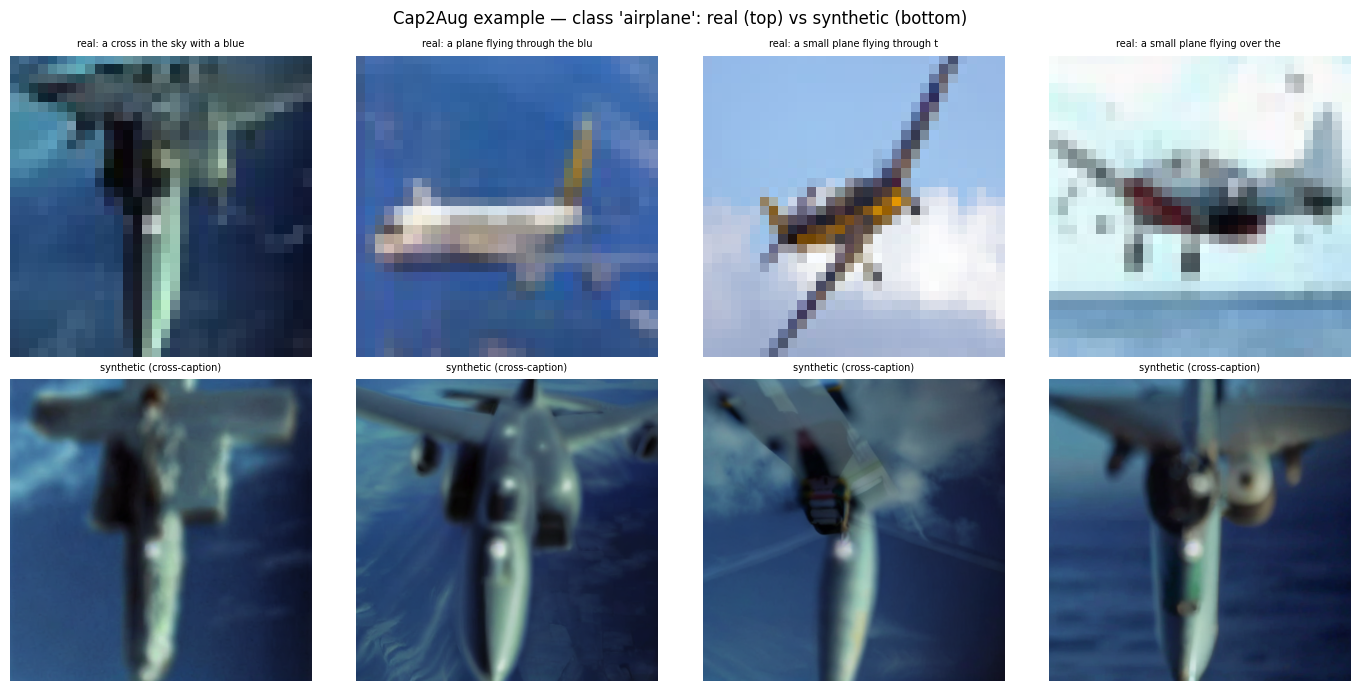

In [6]:

# ---------------------------------------------------------------------------
# 3. Stage 3: MMD loss for domain alignment
# ---------------------------------------------------------------------------

def gaussian_kernel_matrix(x, y, sigmas=(1.0, 2.0, 4.0, 8.0, 16.0)):
    """
    Multi-bandwidth Gaussian RBF kernel matrix between x [N, D] and y [M, D].
    Multiple sigma scales (a standard MMD trick) make the statistic sensitive
    to distributional differences at several scales rather than one fixed one.
    """
    x = x.unsqueeze(1)   # [N, 1, D]
    y = y.unsqueeze(0)   # [1, M, D]
    dist_sq = ((x - y) ** 2).sum(-1)   # [N, M]
    kernel = 0.0
    for sigma in sigmas:
        kernel = kernel + torch.exp(-dist_sq / (2.0 * sigma ** 2))
    return kernel / len(sigmas)


def mmd_loss(real_feats, synth_feats, sigmas=(1.0, 2.0, 4.0, 8.0, 16.0)):
    """
    Standard (biased) MMD^2 estimator:
        MMD^2 = mean(k(x,x')) + mean(k(y,y')) - 2*mean(k(x,y))
    Lower = the two feature distributions look more alike. This is added as
    an auxiliary loss term during classifier training so that gradients also
    push the FUSED SYNTHETIC embeddings toward the real embedding distribution,
    rather than trusting raw synthetic features as-is (Cap2Aug's core fix for
    the real/synthetic domain gap).
    """
    k_xx = gaussian_kernel_matrix(real_feats, real_feats, sigmas)
    k_yy = gaussian_kernel_matrix(synth_feats, synth_feats, sigmas)
    k_xy = gaussian_kernel_matrix(real_feats, synth_feats, sigmas)
    return k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()


# ---------------------------------------------------------------------------
# Probe trainer variants: baseline, naive-synthetic, and MMD-aligned
# ---------------------------------------------------------------------------

def train_probe_baseline(train_feats, labels, test_feats, test_labels_, in_dim,
                          epochs=400, lr=5e-3, weight_decay=1e-3):
    fusion = FusionHead(CLIP_DIM, DINO_DIM, COMMON_DIM).to(DEVICE)
    head = nn.Linear(fusion.out_dim, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(list(fusion.parameters()) + list(head.parameters()),
                                  lr=lr, weight_decay=weight_decay)

    train_feats = train_feats.to(DEVICE)
    labels = labels.to(DEVICE)
    test_feats = test_feats.to(DEVICE)
    test_labels_ = test_labels_.to(DEVICE)

    for epoch in range(epochs):
        fusion.train(); head.train()
        optimizer.zero_grad()
        feats = fusion(train_feats)
        logits = head(feats)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

    fusion.eval(); head.eval()
    with torch.no_grad():
        preds = head(fusion(test_feats)).argmax(-1)
        acc = (preds == test_labels_).float().mean().item()
    return acc, fusion, head


def train_probe_with_mmd(real_feats, real_labels, synth_feats, synth_labels,
                          test_feats, test_labels_, in_dim,
                          epochs=400, lr=5e-3, weight_decay=1e-3, mmd_weight=1.0):
    """
    Trains the SAME FusionHead architecture on real + synthetic data, but adds
    an MMD term between real and synthetic FUSED embeddings to the loss, so
    the network is explicitly encouraged to represent synthetic examples in a
    way that's statistically indistinguishable from real ones (Cap2Aug's
    actual mechanism, rather than just concatenating the two sets naively).
    """
    fusion = FusionHead(CLIP_DIM, DINO_DIM, COMMON_DIM).to(DEVICE)
    head = nn.Linear(fusion.out_dim, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(list(fusion.parameters()) + list(head.parameters()),
                                  lr=lr, weight_decay=weight_decay)

    real_feats = real_feats.to(DEVICE); real_labels = real_labels.to(DEVICE)
    synth_feats = synth_feats.to(DEVICE); synth_labels = synth_labels.to(DEVICE)
    test_feats = test_feats.to(DEVICE); test_labels_ = test_labels_.to(DEVICE)

    all_feats = torch.cat([real_feats, synth_feats], dim=0)
    all_labels = torch.cat([real_labels, synth_labels], dim=0)

    for epoch in range(epochs):
        fusion.train(); head.train()
        optimizer.zero_grad()

        fused_all = fusion(all_feats)
        logits = head(fused_all)
        cls_loss = F.cross_entropy(logits, all_labels)

        fused_real = fused_all[:len(real_feats)]
        fused_synth = fused_all[len(real_feats):]
        domain_loss = mmd_loss(fused_real, fused_synth)

        loss = cls_loss + mmd_weight * domain_loss
        loss.backward()
        optimizer.step()

        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"    epoch {epoch+1}/{epochs}  cls_loss={cls_loss.item():.4f}  "
                  f"mmd_loss={domain_loss.item():.4f}")

    fusion.eval(); head.eval()
    with torch.no_grad():
        preds = head(fusion(test_feats)).argmax(-1)
        acc = (preds == test_labels_).float().mean().item()
    return acc, fusion, head


# ===========================================================================
# End-to-end Cap2Aug demo
# ===========================================================================

def run_cap2aug_demo(strength=0.5, mmd_weight=1.0, epochs=400):
    class_names = CIFAR10_CLASSES

    # --- gather real few-shot images grouped by class (PIL, not yet featurized) ---
    images_by_class = {c: [] for c in class_names}
    labels_by_class = {c: [] for c in class_names}
    for img, lab in train_subset:
        cname = class_names[lab]
        images_by_class[cname].append(img)
        labels_by_class[cname].append(lab)

    # --- Stage 1: BLIP captioning ---
    print("Loading BLIP captioning model...")
    blip_processor, blip_model = load_blip_captioner()
    captions_by_class = {}
    print("Generating captions for each few-shot support image...")
    for cname, images in images_by_class.items():
        captions_by_class[cname] = generate_captions(images, blip_processor, blip_model)
        print(f"  {cname}: {captions_by_class[cname]}")

    if not _HAS_DIFFUSERS:
        print("\ndiffusers not installed — stopping before generation. "
              "Install diffusers/accelerate to run stages 2-3.")
        return None

    # --- Stage 2: cross-image-caption paired img2img generation ---
    print("\nLoading Stable Diffusion img2img pipeline (downloads checkpoint on first run)...")
    pipe = load_img2img_pipeline()
    print("Generating Cap2Aug cross-paired synthetic images (K x K per class)...")
    synthetic_by_class = cap2aug_generate(pipe, images_by_class, captions_by_class, strength=strength)

    synth_images, synth_labels = [], []
    for ci, cname in enumerate(class_names):
        for img in synthetic_by_class[cname]:
            synth_images.append(img)
            synth_labels.append(ci)

    print(f"\nTotal synthetic images generated: {len(synth_images)}")

    # --- feature extraction for synthetic images ---
    print("Extracting CLIP+DINOv2 features for synthetic images...")
    synth_clip, synth_labels_t = extract_clip_features(synth_images, is_pil_list=True, labels=synth_labels)
    synth_dino, _ = extract_dino_features(synth_images, is_pil_list=True, labels=synth_labels)
    synth_concat = torch.cat([synth_clip, synth_dino], dim=-1)

    real_concat = torch.cat([train_clip, train_dino], dim=-1)
    test_concat = torch.cat([test_clip, test_dino], dim=-1)

    # --- (a) baseline: real-only ---
    print("\n[a] Training on REAL few-shot data only...")
    acc_real, _, _ = train_probe_baseline(real_concat, train_labels, test_concat, test_labels,
                                           in_dim=CLIP_DIM + DINO_DIM, epochs=epochs)

    # --- (b) naive: real + synthetic, no domain alignment ---
    print("[b] Training on REAL + SYNTHETIC (naive, no MMD alignment)...")
    naive_concat = torch.cat([real_concat, synth_concat], dim=0)
    naive_labels = torch.cat([train_labels, synth_labels_t], dim=0)
    acc_naive, _, _ = train_probe_baseline(naive_concat, naive_labels, test_concat, test_labels,
                                            in_dim=CLIP_DIM + DINO_DIM, epochs=epochs)

    # --- (c) full Cap2Aug: real + synthetic + MMD domain alignment ---
    print("[c] Training on REAL + SYNTHETIC WITH MMD domain alignment (full Cap2Aug)...")
    acc_mmd, _, _ = train_probe_with_mmd(real_concat, train_labels, synth_concat, synth_labels_t,
                                         test_concat, test_labels, in_dim=CLIP_DIM + DINO_DIM,
                                         epochs=epochs, mmd_weight=mmd_weight)

    print("\n--- Results ---")
    print(f"(a) Real-only few-shot:                        {acc_real*100:.2f}%")
    print(f"(b) Real + synthetic, naive (no alignment):     {acc_naive*100:.2f}%")
    print(f"(c) Real + synthetic + MMD alignment (Cap2Aug): {acc_mmd*100:.2f}%")

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i in range(min(4, len(images_by_class[class_names[0]]))):
        axes[0, i].imshow(images_by_class[class_names[0]][i])
        axes[0, i].set_title(f"real: {captions_by_class[class_names[0]][i][:30]}", fontsize=7)
        axes[0, i].axis("off")
    for i in range(min(4, len(synthetic_by_class[class_names[0]]))):
        axes[1, i].imshow(synthetic_by_class[class_names[0]][i])
        axes[1, i].set_title("synthetic (cross-caption)", fontsize=7)
        axes[1, i].axis("off")
    plt.suptitle(f"Cap2Aug example — class '{class_names[0]}': real (top) vs synthetic (bottom)")
    plt.tight_layout()
    plt.show()

    return {"acc_real": acc_real, "acc_naive_synthetic": acc_naive, "acc_cap2aug": acc_mmd}


if __name__ == "__main__":
    run_cap2aug_demo(strength=0.5, mmd_weight=1.0, epochs=400)